In [1]:
import essentia.standard as es
import numpy as np
import subprocess
import numpy as np
from PIL import Image
import os
import seaborn as sns
import matplotlib.pyplot as plt

2026-08-16 09:17:47.235970: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-08-16 09:17:47.236222: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
[   INFO   ] MusicExtractorSVM: no classifier models were configured by default
2026-08-16 09:17:48.875326: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE3 SSE4.1 SSE4.2 AVX FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-16 09:17:48.880647: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot ope

In [2]:
import os
import glob
import freesound
import random
import pandas as pd
import json
import itertools
import essentia
import numpy as np

import cProfile
import pstats

import IPython.display as ipd
import essentia.standard as es
import matplotlib.pyplot as plt

from datetime import datetime

In [15]:
from helpers import (
    load_and_detect_onsets,
    plot_waveform_with_onsets
)

In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
from IPython.display import HTML
audio_style = "<style>audio { margin-left: 23px; width: 720px; }</style>"
display(HTML(audio_style))

In [6]:
from ck_helpers import load_audio_as_spectrogram_essentia

In [7]:
from ck_helpers import compute_ck1_distance

In [8]:
!ls ../data/audio/pickaxe

240801_2698284-hq.ogg  588306_12594692-hq.ogg  674381_13732472-hq.ogg
362711_6460155-hq.ogg  635702_5685306-hq.ogg


In [9]:
spec1 = load_audio_as_spectrogram_essentia("../data/audio/pickaxe/362711_6460155-hq.ogg")

In [10]:
spec2 = load_audio_as_spectrogram_essentia("../data/audio/pickaxe/240801_2698284-hq.ogg")

In [11]:
spec3 = load_audio_as_spectrogram_essentia("../data/audio/rain/116961_2081635-hq.ogg")

In [12]:
distance = compute_ck1_distance(spec2, spec3)

In [13]:
distance

0.5435197817189632

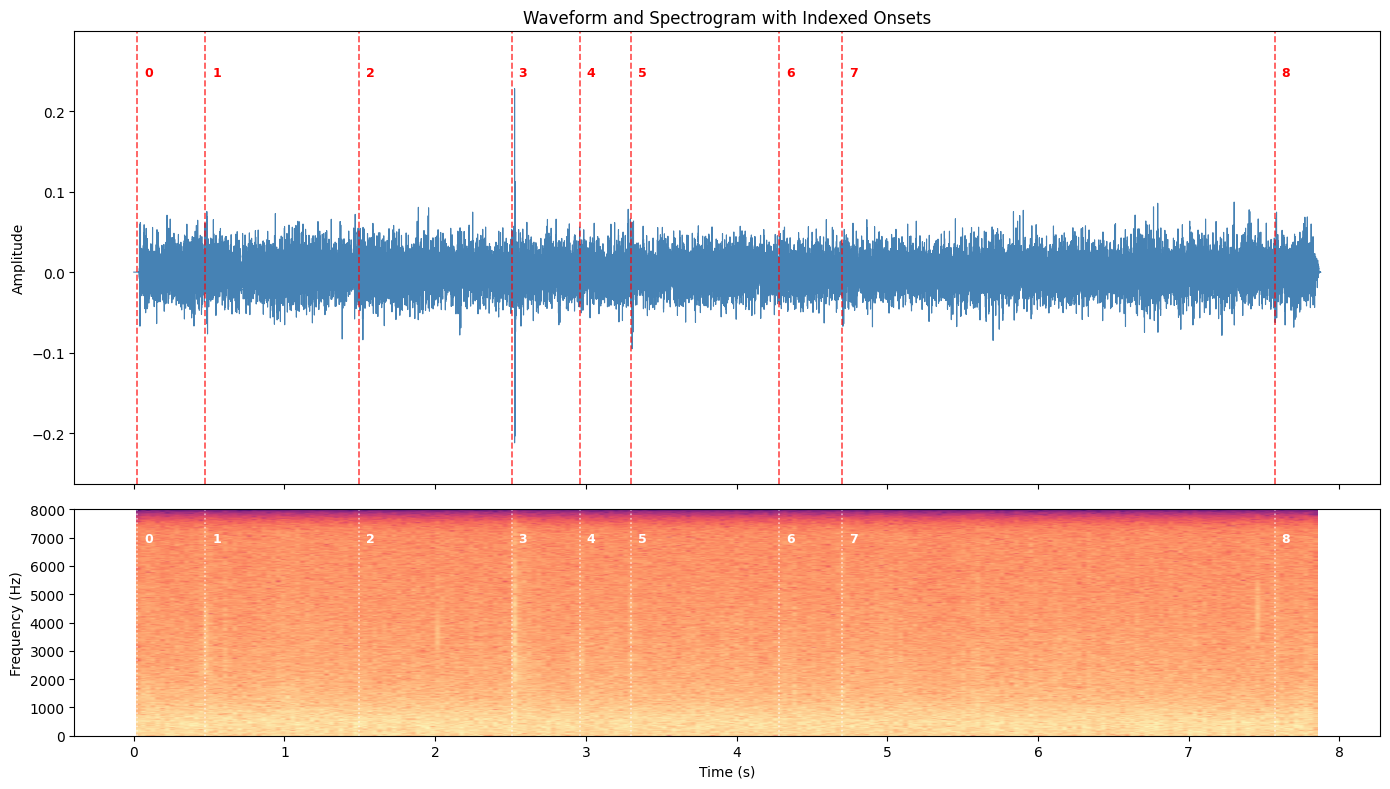

In [16]:
audio, onsets = load_and_detect_onsets("../data/audio/rain/116961_2081635-hq.ogg")
plot_waveform_with_onsets(audio, onsets)
ipd.Audio(audio, rate=16000)

---

In [18]:
from ck_helpers import compute_spectrogram_from_chunk

In [19]:
from ck_helpers import analyze_recording_onsets_ck

In [20]:
df = None
print("Found metadata sources:")
for csv_path in glob.glob(os.path.join("../data/meta", "dataset_*.csv")):
    print(csv_path)

    # figure out the used query based on the query metadata file
    json_path = csv_path[:csv_path.rfind(".")] + ".json"
    with open(json_path, "r") as f:
        query_data = json.load(f)
        
    raw_query = query_data.get("query", "")
    
    # 1. Split at the first " -" to drop all exclusions, and strip any trailing whitespace
    clean_query = raw_query.split(" -")[0].strip()
    
    # 2. Swap double quotes for single quotes to prevent ugly CSV triple-quoting
    # '"3 times"' becomes "'3 times'", 'dog barking' remains 'dog barking'
    clean_query = clean_query.replace('"', "'")
    
    if df is None:
        df = pd.read_csv(csv_path)
        df["search_query"] = clean_query
    else:
        local_df = pd.read_csv(csv_path)
        local_df["search_query"] = clean_query
        df = pd.concat([df, local_df], ignore_index=True)

df = df.drop_duplicates(subset=['sound_id'], keep='first').reset_index(drop=True)

Found metadata sources:
../data/meta/dataset_2026-06-15_14-36-36.csv
../data/meta/dataset_2026-05-20_14-27-00.csv
../data/meta/dataset_2026-06-02_15-32-39.csv
../data/meta/dataset_2026-06-02_16-15-49.csv
../data/meta/dataset_2026-06-12_18-50-48.csv
../data/meta/dataset_2026-06-15_15-18-42.csv
../data/meta/dataset_2026-06-02_18-16-48.csv
../data/meta/dataset_2026-06-13_16-52-26.csv
../data/meta/dataset_2026-06-02_16-24-32.csv
../data/meta/dataset_2026-06-14_09-39-52.csv
../data/meta/dataset_2026-06-13_17-47-59.csv
../data/meta/dataset_2026-06-02_17-59-57.csv
../data/meta/dataset_2026-06-02_17-13-17.csv
../data/meta/dataset_2026-05-23_14-14-52.csv
../data/meta/dataset_2026-06-12_18-26-39.csv
../data/meta/dataset_2026-05-23_14-36-27.csv
../data/meta/dataset_2026-06-02_17-08-15.csv
../data/meta/dataset_2026-06-02_16-21-22.csv
../data/meta/dataset_2026-05-23_14-36-09.csv
../data/meta/dataset_2026-06-12_18-54-51.csv
../data/meta/dataset_2026-06-02_15-40-15.csv
../data/meta/dataset_2026-06-12

In [21]:
with open("../data/annotations5.json", "r") as f:
    annotations = json.load(f)

In [22]:
from pprint import pp
pp(annotations)

{'655124': {'repetitive_onset_indices': [0, 1, 2],
            'repetitive_onset_times': [0.5340589284896851,
                                       2.2639455795288086,
                                       3.8196825981140137]},
 '722978': {'repetitive_onset_indices': [0, 1, 2],
            'repetitive_onset_times': [0.18575963377952576,
                                       0.847528338432312,
                                       1.5092970132827759]},
 '765153': {'repetitive_onset_indices': [0, 1, 2],
            'repetitive_onset_times': [0.743038535118103,
                                       3.3785033226013184,
                                       5.398639678955078]},
 '233665': {'repetitive_onset_indices': [0, 1, 2, 3, 4],
            'repetitive_onset_times': [0.02321995422244072,
                                       0.27863946557044983,
                                       0.41795918345451355,
                                       0.5921088457107544,
                

In [23]:
i = list(df["sound_id"]).index(495658)
i

444

Index 444, annotating sound with id: 495658


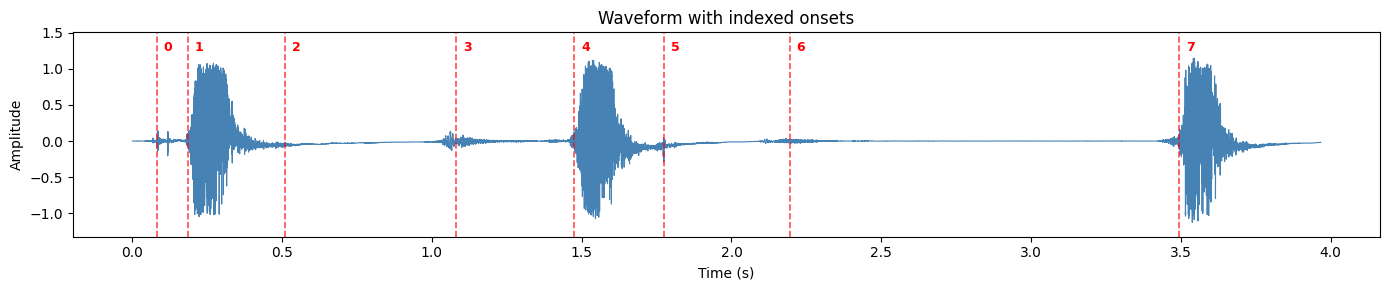

In [32]:
path = df.iloc[i]["local_path"]
sound_id = df.iloc[i]["sound_id"]
print(f"Index {i}, annotating sound with id: {sound_id}")
audio, onsets = load_and_detect_onsets(path)
plot_waveform_with_onsets(audio, onsets, show_spectrogram=False)
ipd.display(ipd.Audio(audio, rate=16000))

Processing: 495658_7932944-hq.ogg
Filtered Onsets to process: 8
Successfully generated 8 onset spectrograms.


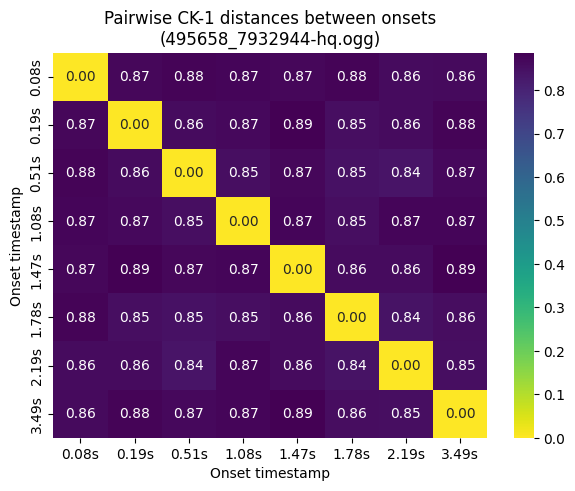

In [33]:
# Pick a row from your dataframe known to contain repeating pickaxe hits
sample_row = df.iloc[i] 
file_path = sample_row['local_path']

# Run the experimental pipeline
matrix, onsets = analyze_recording_onsets_ck(file_path, window_ms=125)

# Plot the matrix as a heatmap
if matrix is not None:
    plt.figure(figsize=(7,5))
    sns.heatmap(
        matrix, 
        cmap="viridis_r", # Reversed viridis: darker colors mean closer to 0 (highly similar)
        xticklabels=[f"{t:.2f}s" for t in onsets],
        yticklabels=[f"{t:.2f}s" for t in onsets],
        annot=True,       # Displays raw CK values in the boxes if onset count is small
        fmt=".2f"
    )
    plt.title(f"Pairwise CK-1 distances between onsets\n({os.path.basename(file_path)})")
    plt.xlabel("Onset timestamp")
    plt.ylabel("Onset timestamp")
    plt.show()

In [26]:
annotations["232929"]["repetitive_onset_indices"]

[3, 5, 7, 9]

In [38]:
matrix

array([[0.        , 0.78694969, 0.80331625, 0.81598785, 0.80851202,
        0.829366  , 0.81153497, 0.817525  , 0.80334701, 0.83971111,
        0.80935205],
       [0.78694969, 0.        , 0.74390175, 0.79804363, 0.73246172,
        0.803747  , 0.73481634, 0.79967365, 0.73821544, 0.8169616 ,
        0.7421014 ],
       [0.80331625, 0.74390175, 0.        , 0.81135855, 0.7397699 ,
        0.81135499, 0.74671031, 0.79769258, 0.74694441, 0.80135056,
        0.74498643],
       [0.81598785, 0.79804363, 0.81135855, 0.        , 0.83533426,
        0.60370181, 0.84148579, 0.6271905 , 0.82420932, 0.64124616,
        0.84242502],
       [0.80851202, 0.73246172, 0.7397699 , 0.83533426, 0.        ,
        0.84997176, 0.76258229, 0.83320844, 0.78031272, 0.83528523,
        0.78375475],
       [0.829366  , 0.803747  , 0.81135499, 0.60370181, 0.84997176,
        0.        , 0.85339952, 0.5853042 , 0.83748502, 0.59822288,
        0.85452121],
       [0.81153497, 0.73481634, 0.74671031, 0.84148579, 0.

In [41]:
def evaluate_matrix_contrast(matrix, group_indices):
    """
    Computes standard intra-cluster, inter-cluster, and out-group metrics.
    
    Parameters:
    - matrix: 2D symmetric NumPy array of pairwise distances
    - group_indices: list or array of target indices (e.g., [3, 5, 7, 9])
    """
    num_elements = matrix.shape[0]
    all_indices = np.arange(num_elements)
    
    # 1. Separate the indices into Group (G) and Non-Group (N)
    g_idx = np.array(group_indices)
    n_idx = np.array([i for i in all_indices if i not in g_idx])
    
    # 2. Average In-Group Distance (Excluding Diagonal Zeros)
    if len(g_idx) > 1:
        in_group_submatrix = matrix[g_idx[:, None], g_idx]
        # Mask out the diagonal elements
        diag_mask = ~np.eye(in_group_submatrix.shape[0], dtype=bool)
        avg_in_group = np.mean(in_group_submatrix[diag_mask])
    else:
        avg_in_group = 0.0  # Not enough elements to have a pair
        
    # 3. Average Out-Group Distance (Excluding Diagonal Zeros)
    if len(n_idx) > 1:
        out_group_submatrix = matrix[n_idx[:, None], n_idx]
        diag_mask_n = ~np.eye(out_group_submatrix.shape[0], dtype=bool)
        avg_out_group = np.mean(out_group_submatrix[diag_mask_n])
    else:
        avg_out_group = 0.0
        
    # 4. Average Between Group and Non-Group Distance
    if len(g_idx) > 0 and len(n_idx) > 0:
        between_submatrix = matrix[g_idx[:, None], n_idx]
        avg_between = np.mean(between_submatrix)
    else:
        avg_between = 0.0
        
    # 5. Compute Contrast Ratio
    contrast_ratio = avg_between / avg_in_group if avg_in_group > 0 else 0.0
    
    return {
        "Avg In-Group (Intra)": avg_in_group,
        "Avg Out-Group": avg_out_group,
        "Avg Between (Inter)": avg_between,
        "Contrast Ratio": contrast_ratio
    }

In [63]:
evaluate_matrix_contrast(matrix, [1, 4, 5])

{'Avg In-Group (Intra)': np.float64(0.8334000967827642),
 'Avg Out-Group': np.float64(0.6488850390878739),
 'Avg Between (Inter)': np.float64(0.8146704577424049),
 'Contrast Ratio': np.float64(0.9775262336629637)}